In [ ]:
!pip install --pre -U langchain langchain-openai langchain_community langchain_core langchain_text_splitters  unstructured langchain_huggingface langchain_cohere

In [ ]:
!pip install langchain-chroma

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import LlamaTokenizer ,LlamaForCausalLM ,GenerationConfig ,pipeline ,AutoTokenizer ,AutoModelForCausalLM
import torch
from langchain_huggingface  import HuggingFacePipeline,ChatHuggingFace

In [ ]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
hf_pipeline = pipeline(
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    task='text-generation',
    max_new_tokens = 256,
    max_length = None,
    temperature = 0.1,
)

In [ ]:
llm = HuggingFacePipeline(pipeline = hf_pipeline)

In [ ]:
from google.colab import userdata
import os
langsmith_api_key = userdata.get('LANGSMITH')

os.environ['LANGCHAIN_TRACING'] = 'true'
os.environ['LANGCHAIN_API_KEY'] = langsmith_api_key

## simple RAG

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_cohere import CohereEmbeddings
from langchain_chroma import Chroma
import chromadb

from google.colab import userdata

In [ ]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

In [ ]:
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

In [ ]:
# splitting
text_splitter = RecursiveCharacterTextSplitter(
chunk_size = 1000,
chunk_overlap  = 200,
length_function = len,
)


In [ ]:
doc_splits = text_splitter.split_documents(docs_list)

In [ ]:
# embedding
from google.colab import userdata
cohere_Api_key = userdata.get('cohere')

embedding_llm = CohereEmbeddings(
    cohere_api_key=cohere_Api_key,
    model="embed-english-v3.0")

In [ ]:
vector_db = Chroma.from_documents(
    documents = doc_splits,
    embedding = embedding_llm,
    persist_directory = "./chroma_vdb"
)

In [ ]:
quistion = 'what is llm agent'

similer_docs = vector_db.similarity_search(quistion,k=2)

similer_docs

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains.question_answering import load_qa_chain

In [ ]:
def rag_bot(quistion : str)->str:
  similarity = vector_db.similarity_search(quistion,k=5)

  initial_qna_template = "\n".join([
      "Answer the question using the provided context.",
      "If the answer is not in context, say 'NO ANSWER AVAILABLE'",
      "",
      "Context:",
      "{context_str}",
      "",
      "Question:",
      "{question}",
      "",
      "Answer:"
  ])

  qna_prompt = PromptTemplate(
      template = initial_qna_template,
      input_variables = ["context_str","question"],
      verbose = True
  )

  refine_qna_template = "\n".join([
      "Refine the existing answer, if required,with the following context",
      "if answer is not avialabel , say 'NO ANSWER AVAILABLE'",
      "### Context:",
      "{context_str}","",
      "### Existing Answer:",
      "{existing_answer}","",
      "### Quistion:",
      "{question}",
      "### Answer:",
  ]
  )
  refine_qna_prompt = PromptTemplate(
      template = refine_qna_template,
      input_variables = ["context_str","existing_answer","question"],
      verbose = True
  )

  refine_chain = load_qa_chain(llm,
                              chain_type = "refine" ,

                              question_prompt = qna_prompt,
                              refine_prompt = refine_qna_prompt)

  answer = refine_chain(
      {
        "input_documents": similarity,
        "question": quistion

      },
      return_only_outputs = True
  )

  return {'answer':answer['output_text']}


## Dataset

In [ ]:
from langsmith import Client

client= Client()

examples = [
    {
        "inputs": {"question": "How does the ReAct agent use self-reflection? "},
        "outputs": {"answer": "ReAct integrates reasoning and acting, performing actions - such tools like Wikipedia search API - and then observing / reasoning about the tool outputs."},
    },
    {
        "inputs": {"question": "What are the types of biases that can arise with few-shot prompting?"},
        "outputs": {"answer": "The biases that can arise with few-shot prompting include (1) Majority label bias, (2) Recency bias, and (3) Common token bias."},
    },
    {
        "inputs": {"question": "What are five types of adversarial attacks?"},
        "outputs": {"answer": "Five types of adversarial attacks are (1) Token manipulation, (2) Gradient based attack, (3) Jailbreak prompting, (4) Human red-teaming, (5) Model red-teaming."},
    },
    {
        "inputs": {"question": "What are the main components of an LLM-powered autonomous agent?"},
        "outputs": {
            "answer": "The main components of an LLM-powered autonomous agent are planning, memory, and tool use."
        },
    },
    {
        "inputs": {"question": "What is Chain-of-Thought prompting?"},
        "outputs": {
            "answer": "Chain-of-Thought prompting is a technique where the model is encouraged to generate intermediate reasoning steps before producing the final answer."
        },
    },
    {
        "inputs": {"question": "What is self-consistency in prompting?"},
        "outputs": {
            "answer": "Self-consistency improves reasoning by sampling multiple reasoning paths and selecting the most consistent final answer among them."
        },
    },
    {
        "inputs": {"question": "What is retrieval-augmented generation in LLM agents?"},
        "outputs": {
            "answer": "Retrieval-augmented generation allows agents to retrieve external knowledge from sources such as vector databases, search engines, or APIs to improve responses."
        },
    },
    {
        "inputs": {"question": "What is prompt injection?"},
        "outputs": {
            "answer": "Prompt injection is an adversarial attack where malicious instructions are inserted into the input to manipulate the model's behavior."
        },
    },
    {
        "inputs": {"question": "What is Tree of Thoughts prompting?"},
        "outputs": {
            "answer": "Tree of Thoughts prompting enables deliberate problem solving by exploring multiple reasoning branches and evaluating different paths before selecting the best solution."
        },
    },
    {
        "inputs": {"question": "What are examples of external tools used by LLM agents?"},
        "outputs": {
            "answer": "Examples of external tools used by LLM agents include search engines, calculators, APIs, code interpreters, and databases."
        },
    }
]

In [ ]:
# create the dataset in Langsmith

dataset_name = "RAG Evaluation"

dataset = client.create_dataset(
    dataset_name = dataset_name,
)

client.create_examples(
    dataset_id = dataset.id,
    examples = examples
)

# Evaluation

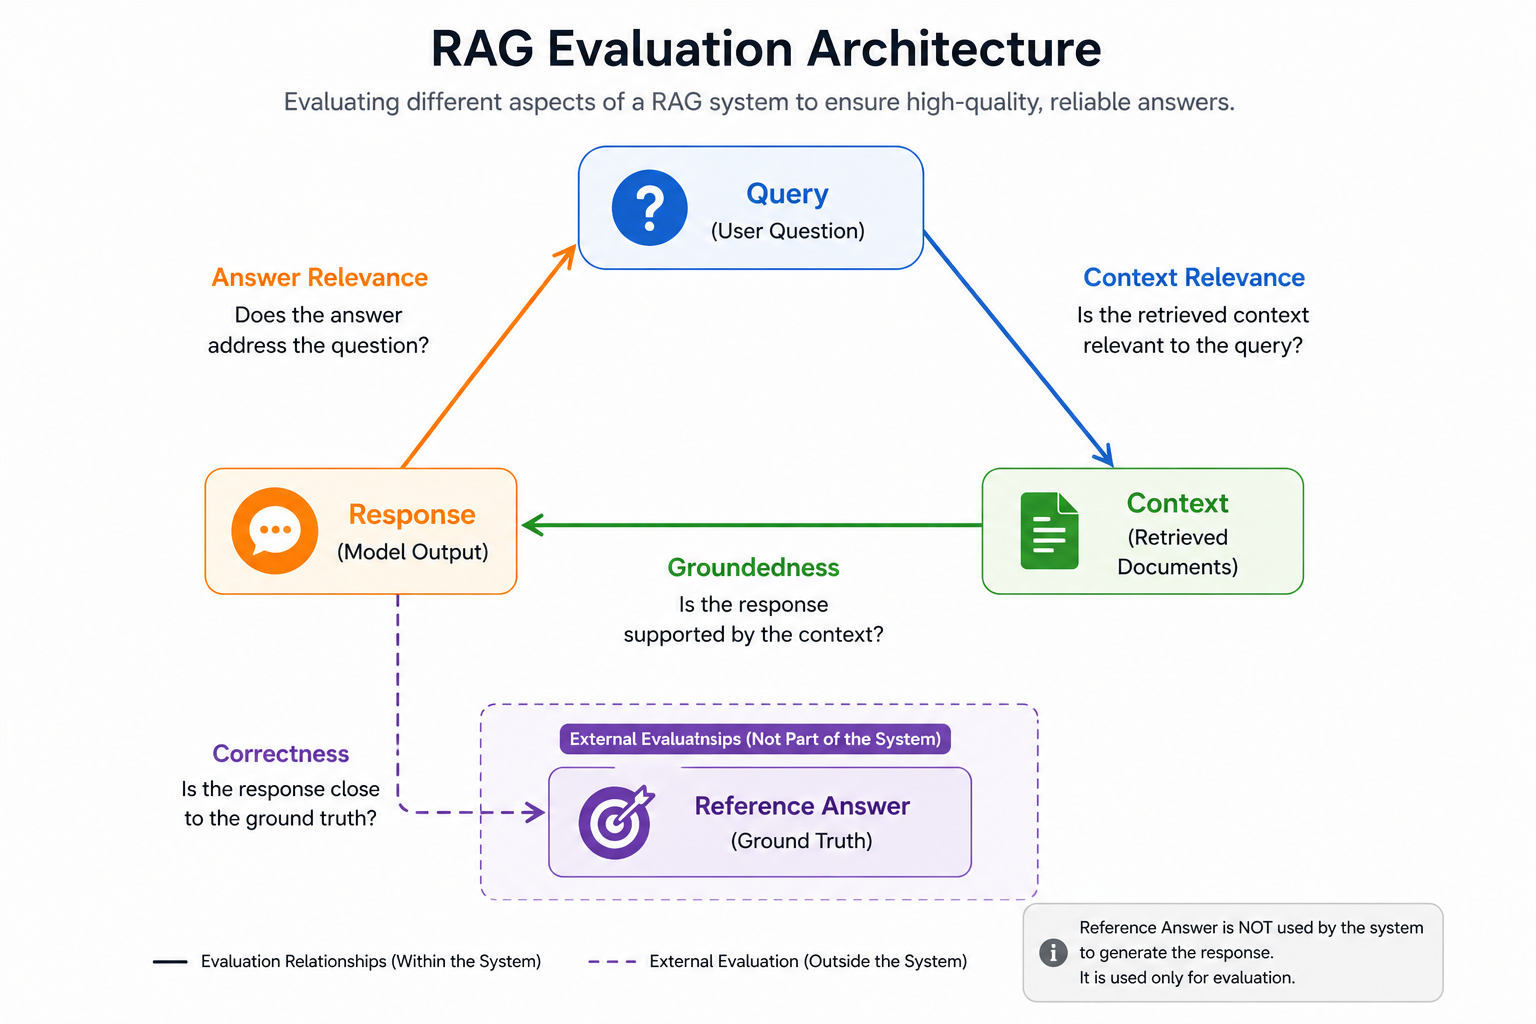

### 1- Correctness: Response vs reference answer

Goal: Measure "how similar/correct is the RAG chain answer, relative to a ground-truth answer"
Mode: Requires a ground truth (reference) answer supplied through a dataset
Evaluator: Use LLM-as-judge to assess answer correctness.



In [ ]:
from typing_extensions import Annotated,TypedDict
from pydantic import BaseModel, ValidationError


# correctness Output Schema

#grade outputschema

class CorrectnessGrade(TypedDict):
    # Note that the order in the fields are defined is the order in which the model will generate them.
    # It is useful to put explanations before responses because it forces the model to think through
    # its final response before generating it:
    explination: Annotated[str, ... , "Explain you reason for the score"]
    correct : Annotated[bool, ... ,"True if the answer is correct, False otherwise"]


## correctness prompt
correctness_instruction = """You are a teacher grading a quiz.
You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER.
Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer.
(2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the  ground truth answer.
Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.
Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.
Avoid simply stating the correct answer at the outset."""


## evaluator

def correctness(inputs:dict , outputs:dict , reference_outputs:dict)->bool:
  user_content = f""" An Evaluatorfor RAG Answer Correctness
  QUESTION:{inputs['question']}
  GROUND TRUTH ANSWER:{reference_outputs['answer']}
  STUDENT ANSWER:{outputs['answer']}

          Instructions:
          - Respond with ONLY one word.
          - Allowed answers: CORRECT or INCORRECT
          - Do not explain.

  grade:"""
  messages=[
                  {"role":"system","content":correctness_instruction},
                  {"role":"user","content":user_content}
            ]

  text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
      )

  inputs = tokenizer([text], return_tensors="pt").to(model.device)

  outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.1
        )

  generated_ids = outputs[0][inputs.input_ids.shape[1]:]

  response = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
      )
  return response.strip() == "CORRECT"


### 2- Answer Relevance: Response vs input

The flow is similar to above, but we simply look at the inputs and outputs without needing the reference_outputs. Without a reference answer we can't grade accuracy, but can still grade relevance—as in, did the model address the user's question or not.

In [ ]:
# Grade output schema

class RelevantGrad(TypedDict):
  explanation:Annotated[str, ...,'Explain you reason for the score']
  relevance : Annotated[bool,...,"True if the answer is relevant, False otherwise"]


relevance_instruction = """
You are a teacher grading a quiz.
You will be given a QUESTION and a STUDENT ANSWER.
Here is the grading criteria to follow:
(1) Grade the student answer based ONLY on whether it is relevant to the QUESTION.
(2) The answer must directly address the user's question or intent.
(3) The answer should stay on topic and should not include unrelated information that fails to answer the question.
(4) It is acceptable if the answer contains additional information, as long as the answer remains relevant to the question.
Answer Relevance:
A relevance value of True means that the student's answer is relevant to the question and appropriately addresses what was asked.
A relevance value of False means that the student's answer is irrelevant, off-topic, avoids answering the question, or does not address the user's intent.
Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.
Avoid simply stating the final judgment at the outset.
"""

def relevance(inputs:dict , outputs:dict )->bool:
  user_content = f""" An Evaluatorfor RAG Answer Relevance
  QUESTION:{inputs['question']}
  STUDENT ANSWER:{outputs['answer']}

          Instructions:
          - Respond with ONLY one word.
          - Allowed answers: CORRECT or INCORRECT
          - Do not explain.

  grade:"""
  messages=[
                  {"role":"system","content":correctness_instruction},
                  {"role":"user","content":user_content}
            ]

  text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
      )

  inputs = tokenizer([text], return_tensors="pt").to(model.device)

  outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.1
        )

  generated_ids = outputs[0][inputs.input_ids.shape[1]:]

  response = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
      )
  return response.strip() == "CORRECT"


### Groundedness

Another useful way to evaluate responses without needing reference answers is to check if the response is justified by (or "grounded in") the retrieved documents.

In [ ]:
# Grade output schema

class GroundedGrade(TypedDict):
  explanation:Annotated[str, ...,'Explain you reason for the score']
  grounded : Annotated[bool,...,"True if the answer is relevant, False otherwise"]


relevance_instruction = """You are a teacher grading a quiz.
You will be given a CONTEXT and a STUDENT ANSWER.
Here is the grading criteria to follow:
(1) Grade the student answer based ONLY on whether it is fully supported by the provided CONTEXT.
(2) The student answer must not include claims, facts, or details that are not explicitly stated or clearly implied in the CONTEXT.
(3) If the student answer contains hallucinated, unsupported, or fabricated information, it should be marked as False.
(4) It is acceptable if the student answer is shorter than the context or omits some details, as long as all included information is grounded in the provided context.
Groundedness:
A groundedness value of True means that all statements in the student answer are fully supported by the provided context.
A groundedness value of False means that the student answer includes unsupported, fabricated, or contradictory information not grounded in the context.
Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.
Avoid simply stating the final judgment at the outset.
"""

def groundedness(inputs:dict , outputs:dict )->bool:
  user_content = f""" An Evaluatorfor RAG Answer groundedness
  QUESTION:{inputs['question']}
  STUDENT ANSWER:{outputs['answer']}

          Instructions:
          - Respond with ONLY one word.
          - Allowed answers: CORRECT or INCORRECT
          - Do not explain.

  grade:"""
  messages=[
                  {"role":"system","content":correctness_instruction},
                  {"role":"user","content":user_content}
            ]

  text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
      )

  inputs = tokenizer([text], return_tensors="pt").to(model.device)

  outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.1
        )

  generated_ids = outputs[0][inputs.input_ids.shape[1]:]

  response = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
      )
  return response.strip() == "CORRECT"

### context Retrival

In [ ]:
# Grade output schema

class RetrievalRelevanceGrade(TypedDict):
  explanation:Annotated[str, ...,'Explain you reason for the score']
  relevant : Annotated[bool,...,"True if the answer is relevant, False otherwise"]


relevance_instruction = """You are a teacher grading a quiz.

You will be given a QUESTION and a RETRIEVED CONTEXT.

Here is the grading criteria to follow:

(1) Grade the retrieved context based ONLY on whether it contains information relevant to answering the QUESTION.

(2) The retrieved context should include the necessary information needed to answer the question correctly.

(3) If the retrieved context is irrelevant, off-topic, or missing key information required to answer the question, it should be marked as False.

(4) The retrieved context may contain additional information, as long as it still includes relevant information needed to answer the question.

Context Retrieval Relevance:

A retrieval value of True means that the retrieved context is relevant and contains sufficient information to help answer the question.

A retrieval value of False means that the retrieved context is irrelevant, incomplete, or does not provide enough information to answer the question.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.

Avoid simply stating the final judgment at the outset.
"""

def retrieval_relevance(inputs:dict , outputs:dict )->bool:
  user_content = f""" An Evaluatorfor RAG Answer Groundness
  QUESTION:{inputs['question']}
  STUDENT ANSWER:{outputs['answer']}

          Instructions:
          - Respond with ONLY one word.
          - Allowed answers: CORRECT or INCORRECT
          - Do not explain.

  grade:"""
  messages=[
                  {"role":"system","content":correctness_instruction},
                  {"role":"user","content":user_content}
            ]

  text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
      )

  inputs = tokenizer([text], return_tensors="pt").to(model.device)

  outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.1
        )

  generated_ids = outputs[0][inputs.input_ids.shape[1]:]

  response = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
      )
  return response.strip() == "CORRECT"

## Run Evaluation

In [ ]:
def target(inputs: dict) -> dict:
    return rag_bot(inputs["question"])

experiment_results = client.evaluate(
    target,
    data=dataset_name,
    evaluators=[correctness, groundedness, relevance, retrieval_relevance],
    experiment_prefix="rag-doc-relevance",
    metadata={"version": "Qwen2.5-7B-Instruct-V1.0-previewpre"},
)
# Explore results locally as a dataframe if you have pandas installed
experiment_results.to_pandas()